In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as m_colors
import seaborn as sns
import pandas as pd
import string
from tqdm.auto import trange
import scipy
import scipy.stats as stats

from src.util import (complexity, 
                      informativity,
                      letter_subplots,
                      degree_of_convexity_cielab)

from src.colorconv import ConvexCluster

sns.set(context='paper', 
        style='ticks', 
        font_scale=1.1,
        font='serif',
        )

In [187]:
def c_i(lgs, pU_m, p_m):
    '''
    Function to compute the complexity and accuracy for a set of p(w|m)
    '''
    c = []
    i = []

    for lg in lgs:
        c.append(complexity(lg, p_m))
        i.append(informativity(lg, pU_m, p_m))

    return c, i


In [188]:
def compute_pU_m_d(sigma, coords_correct):
    pU_m_d = np.zeros((len(coords_correct), len(coords_correct)))
    
    for i_, i in enumerate(coords_correct):
        for j_, j in enumerate(coords_correct):
            d = np.exp(- (1 / (2 * sigma ** 2)) * np.linalg.norm(np.array(i) - np.array(j))**2)
            pU_m_d[i_, j_] = d
    
    pU_m_d /= pU_m_d.sum(axis=1)[:, np.newaxis]
    
    return pU_m_d

In [189]:
def _ib(p_x, p_y_x, gamma, init, num_iter=100, temperature = 1):
    """ Find encoder q(Z|X) to minimize J = I[X:Z] - gamma * I[Y:Z].
    
    Input:
    p_x : Distribution on X, of shape X. (p(m))
    p_y_x : Conditional distribution on Y given X, of shape X x Y.
    gamma : A non-negative scalar value.
    Z : Support size of Z.

    Output: 
    Conditional distribution on Z given X, of shape X x Z.

    """
    # Randomly initialize the conditional distribution q(z|x)
    q_z_x = init #scipy.special.softmax(np.random.randn(X, Z), -1) # shape X x Z
    p_y_x = p_y_x[:, None, :] # shape X x 1 x Y
    p_x = p_x[:, None] # shape X x 1

    # Blahut-Arimoto iteration to find the minimizing q(z|x)
    for _ in range(num_iter):
        q_xz = p_x * q_z_x # Joint distribution q(x,z), shape X x Z
        q_z = q_xz.sum(axis=0, keepdims=True) # Marginal distribution q(z), shape 1 x Z
        q_y_z = ((q_xz / q_z)[:, :, None] * p_y_x).sum(axis=0, keepdims=True) # Conditional decoder distribution q(y|z), shape 1 x Z x Y
        d = ( 
            scipy.special.xlogy(p_y_x, p_y_x)
            - scipy.special.xlogy(p_y_x, q_y_z) # negative KL divergence -D[p(y|x) || q(y|z)]
        ).sum(axis=-1) # expected distortion over Y; shape X x Z
        q_z_x = scipy.special.softmax((np.log(q_z) - gamma*d)/temperature, axis=-1) # Conditional encoder distribution q(z|x) = 1/Z q(z) e^{-gamma*d}

    return q_z_x

In [190]:
def compute_ib_curve(p_m_u, pU_m_d, p_w_m, beta_range=(1, 0.00001, 100), num_iter=1):
    """
    Compute the IB curve and rotated WCS data
    """
    # Define the beta range
    betas = np.geomspace(*beta_range)
    
    # Compute the IB curve
    opt_lg = []
    for beta in betas:
        opt_lg.append(_ib(p_m_u.squeeze(), pU_m_d, beta, 
                          np.eye(p_m_u.shape[0]), num_iter=num_iter))
    
    # Compute original capacity and information
    c, i = c_i(p_w_m, pU_m_d, p_m_u)
    
    # Compute IB curve based on the optimal lg values
    ib_curve_ = c_i(opt_lg, pU_m_d, p_m_u)
    
    # Return results as a dictionary
    return {
        'opt_lg': opt_lg,
        'c': c,
        'i': i,
        'ib_curve': ib_curve_
    }


In [191]:
with open('data/pU_M.pkl', 'rb') as f:
    pU_m = pickle.load(f)

with open('data/pM.pkl', 'rb') as f:
    p_m = pickle.load(f)

with open('data/wcs_encoders.pkl', 'rb') as f:
    p_w_m = pickle.load(f)

with open('data/IB_color_naming.pkl', 'rb') as f:
    ib = pickle.load(f)

In [192]:
print(f'min shape: {min([i.shape[1] for i in p_w_m])} \nmax shape: {max([i.shape[1] for i in p_w_m])}')

min shape: 4 
max shape: 80


In [193]:
# unpickle chip dict
with open('data/chip_dict.pkl', 'rb') as f:
    chip_dict = pickle.load(f)

# unpickle sielab_dict
with open('data/cielab_dict.pkl', 'rb') as f:
    cielab_dict = pickle.load(f)   

# unpickle rgb_dict
with open('data/rgb_dict.pkl', 'rb') as f:
    rgb_dict = pickle.load(f)

# unpickle languages
with open('data/lg_color.pkl', 'rb') as f:
    lg_color = pickle.load(f)

In [234]:
for lg in lg_color:
    lg_color[lg] = np.where(lg_color[lg] == -1, np.nan, lg_color[lg])

In [194]:
# Constants
ROWS = [string.ascii_uppercase[i] for i in range(10)]  # ['A', 'B', ..., 'J']

# Load WCS data
WCS_CNUM_FILE = 'data/raw/chip.txt'  # Replace with actual path to chip.txt
WCS_CNUMS = pd.read_csv(WCS_CNUM_FILE, delimiter='\t', header=None).values

# Create mapping between chip numbers and coordinates
CNUMS_WCS_COR = dict(zip(
    WCS_CNUMS[:, 0],  # Chip number
    [(ROWS.index(WCS_CNUMS[cnum - 1, 1]), WCS_CNUMS[cnum - 1, 2]) for cnum in WCS_CNUMS[:, 0]]  # (row, column)
))

# Build DataFrame for fast lookups
DF = pd.DataFrame({'cnum': np.arange(1, 331)})
DF['x'] = DF['cnum'].apply(lambda x: CNUMS_WCS_COR[x][0])
DF['y'] = DF['cnum'].apply(lambda x: CNUMS_WCS_COR[x][1])
DF.set_index(['x', 'y'], inplace=True)

def ind2cnum(x, y):
    """
    Convert location in the WCS palette to chip number.
    Example: ind2cnum(2, 22) returns 100.
    """
    return DF.loc[x, y]['cnum']

In [195]:
def clean_partition(partition):
    """
    Normalizes the values in the partition to sequential integers (0 to voc_size - 1),
    ignoring NaN values.
    """
    unique_vals = np.unique(partition[~np.isnan(partition)])  # Ignore NaN for unique values
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    # Vectorize the mapping, explicitly checking for NaN
    return np.vectorize(lambda x: mapping.get(x, -1))(partition)

def binary(partition):
    """
    Converts a partition matrix into a one-hot encoded matrix.
    Handles special cases for outlier chips.
    """
    # Normalize the partition
    # partition = clean_partition(partition)

    # Determine vocabulary size
    voc_size = len(np.unique(partition[~np.isnan(partition)])) + 1  # Exclude NaN

    # Initialize the encoder matrix
    encoder = np.zeros((330, voc_size))

    # Fill in the one-hot encoding
    for i in range(partition.shape[0]):  # Loop through rows
        for j in range(partition.shape[1]):  # Loop through columns
            if np.isnan(partition[i, j]):  # Skip NaN values
                pass
            else:
                # chip_index = int(ind2cnum(i + 1, j) - 1)  # Convert to chip index
                chip_index = int(ind2cnum(i, j))  # Convert to chip index
                word_index = int(partition[i, j])  # Use normalized value as index
                encoder[chip_index - 1, word_index] = 1.0

    # # Handle the outlier chips
    # encoder[140, partition[0, 0]] = 1.0  # Assign value from (1, 0)
    # encoder[88, partition[7, 0]] = 1.0   # Assign value from (8, 0)

    # Validate the encoding
    # if not np.all(np.sum(encoder, axis=1) == 1.0):
    #     raise ValueError("The probability distribution is not normalized!")

    return encoder

In [227]:
cielab_dict_ = {k: v for k, v in cielab_dict.items() if k[0] in range(-1, 9) and k[1] in range(-1, 41)}

# reverse keys and values in cielab_dict_
cielab_dict_r = {v: k for k, v in cielab_dict_.items()}

# convert cielab_dict_ to a list of tuples ordered from (0, 0) to (8, 40)
cielab_list = [cielab_dict_[k] for k in sorted(cielab_dict_.keys())]

In [200]:
p_m_u = np.ones(330) / 330
p_m_u = p_m_u[:, None]

In [201]:
np.zeros((9, 40)).size

360

In [212]:
def gen_convex(N):
    S = np.random.uniform(0.1, 1)
    C = np.random.uniform(0.0001, 0.1)
    a = ConvexCluster(X = np.zeros((10, 41)), 
                      d = 10, 
                      N = N, 
                      s = S, 
                      c = C,
                      coords = cielab_list,
                      reverse_labels = cielab_dict_r,
                      p=p_m.squeeze())
    labels = a.run()
    # labels = np.hstack((labels[:, -1][:, np.newaxis], labels[:, :-1]))
    # move the last row on top
    labels = np.vstack((labels[-1, :], labels[:-1, :]))
    # move the last column first
    labels = np.hstack((labels[:, -1][:, np.newaxis], labels[:, :-1]))
    try:
        return binary(labels), labels, a.degree_of_convexity(), S, C
    except:
        return None

Text(0.5, 1.0, 'c = 0.74')

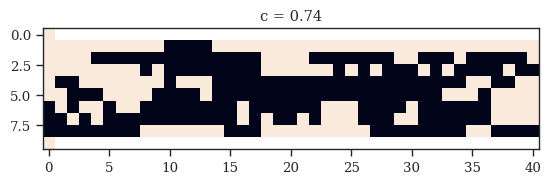

In [213]:
b_l, l, conv, S_, C_ = gen_convex(N=2)

plt.imshow(l)
plt.title(f'c = {conv:.2f}')

In [214]:
# number of non na values in l
np.count_nonzero(~np.isnan(l))

330

In [145]:
convex_lgs = [gen_convex(N=np.random.randint(3, 16)) for _ in trange(30000)]

  0%|          | 0/5000 [00:00<?, ?it/s]

In [146]:
convex_lgs = [i for i in convex_lgs if i is not None]

In [147]:
convex_lgs[0][0].shape

(330, 16)

In [148]:
# pU_m_d = compute_pU_m_d(np.sqrt(64), cielab_list)
# pU_m_d.shape

cielab_coords = pd.read_csv('data/raw/cnum-vhcm-lab-new.txt', sep='\t')
coords_correct = cielab_coords.sort_values(by='#cnum')[['L*', 'a*', 'b*']].values.tolist()

pU_m_d = np.zeros((330, 330))
sigma = 8

for i_, i in enumerate(coords_correct):
    for j_, j in enumerate(coords_correct):
        d = np.exp( - (1 / (2 * sigma ** 2)) * np.linalg.norm(np.array(i) - np.array(j)) ** 2)
        pU_m_d[i_, j_] = d

pU_m_d /= pU_m_d.sum(axis=1)[:,np.newaxis]

In [366]:
c_c = []
i_c = []

for lg in [_[0] for _ in convex_lgs]:
    c_c.append(complexity(lg, p_m))
    i_c.append(informativity(lg, pU_m_d, p_m))

In [244]:
c_n = []
i_n = []

for lg in [binary(i) for i in lg_color.values()]:
    c_n.append(complexity(lg, p_m))
    i_n.append(informativity(lg, pU_m_d, p_m))

In [151]:
IB_c = compute_ib_curve(p_m,
                        pU_m_d, 
                        [_[0] for _ in convex_lgs], 
                        beta_range=(100, 0.00001, 100), 
                        num_iter=1)

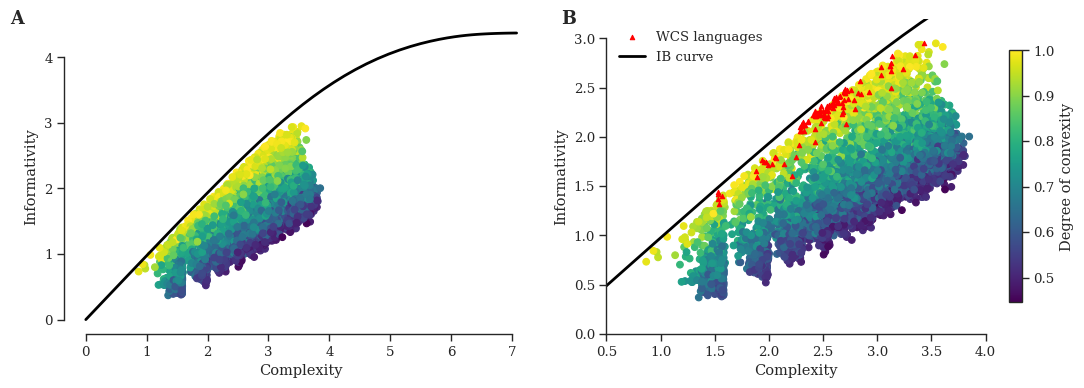

In [301]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

letter_subplots()

# First subplot
axes[0].scatter(c_c, 
                i_c, 
                c=[_[2] for _ in convex_lgs],
                norm=m_colors.Normalize(vmin=min([_[2] for _ in convex_lgs]), 
                                        vmax=1),
                cmap='viridis')
# axes[0].scatter(c_n, 
#                 i_n, 
#                 c='red', 
#                 s=10,
#                 alpha=1)
axes[0].plot(IB_c['ib_curve'][0], 
             IB_c['ib_curve'][1], 
             linewidth=2, 
             color='black')
sns.despine(ax=axes[0], 
            # offset=1, 
            trim=True)
axes[0].set_xlabel('Complexity')
axes[0].set_ylabel('Informativity')

# Second subplot
sc = axes[1].scatter(c_c, 
                     i_c, 
                     c=[_[2] for _ in convex_lgs],
                     norm=m_colors.Normalize(vmin=min([_[2] for _ in convex_lgs]), 
                                             vmax=1),
                     cmap='viridis')
axes[1].scatter(c_n, 
                i_n, 
                c='red',
                s=10, 
                label='WCS languages',
                marker='^')
axes[1].plot(IB_c['ib_curve'][0], 
             IB_c['ib_curve'][1], 
             linewidth=2, 
             color='black', 
             label='IB curve')
axes[1].set_xlim(0.5, 4)
axes[1].set_ylim(0, 3.2)
sns.despine(ax=axes[1], 
            # offset=10, 
            trim=True)
axes[1].set_xlabel('Complexity')
axes[1].set_ylabel('Informativity')
# fig.colorbar(sc, ax=axes[1])
cbar1 = fig.colorbar(sc, ax=axes[1], shrink=0.8, 
                     label='Degree of convexity')

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [367]:
c, i = c_i(IB_c['opt_lg'], pU_m, p_m)

In [402]:
# make a function that return the informativity value given a complexity value based on c and i
def infor_c(c, i, c_):
    return i[np.argmin(np.abs(np.array(c) - c_))]

In [403]:
# now compute the distance between the closest opt language and convex languages
distances = []

# # use c_c and i_c to compute the distance to the closest c and i
# for c_, i_ in zip(c_c, i_c):
#     distances.append(np.min(np.sqrt((c_ - np.array(c))**2 + (i_ - np.array(i))**2)))
# compute distances using the i_c function (diff between informativity values and the i_c informativity values
for c_, i_ in zip(c_c, i_c):
    distances.append((i_ - infor_c(c, i, c_))**2)

In [404]:
conv = np.array([_[2] for _ in convex_lgs])

In [405]:
# now do the same for the WCS languages

distances_wcs = []

for c_, i_ in zip(c_n, i_n):
    # distances_wcs.append(np.min(np.sqrt((c_ - np.array(c))**2 + (i_ - np.array(i))**2)))
    distances_wcs.append((i_ - infor_c(c, i, c_))**2)

convexity_values = degree_of_convexity_cielab(np.array([lg_color[lg] for lg in list(lg_color.keys())]), 
                                              cielab_dict_, cielab_list)
categories_values = [len(np.unique(lg_color[grid])) - 1 for grid in lg_color]

In [406]:
len(convexity_values)

103

In [407]:
len(distances_wcs)

103

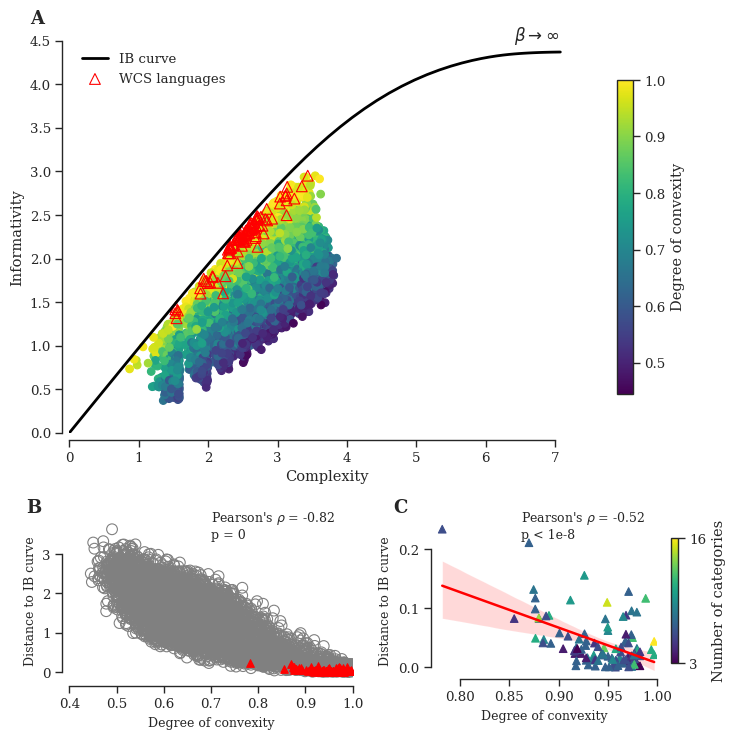

In [415]:
# Create a helper function to format p-value automatically
def format_p(p):
    if p == 0:
        return "p = 0"
    n = int(np.floor(np.log10(p)))
    return f"p < 1e{n}"

# Create a GridSpec for the layout: top plot spans both columns
fig = plt.figure(figsize=(7.5, 7.5))
gs = fig.add_gridspec(2, 2, height_ratios=[2.5, 1])  # 2 rows, 2 columns with different heights

# SUBPLOT A
ax1 = fig.add_subplot(gs[0, :])  # Span the entire top row
ax1.plot(IB_c['ib_curve'][0], IB_c['ib_curve'][1], linestyle='-', 
         color='black', linewidth=2, label='IB curve')
scatter1 = ax1.scatter(c_c, 
            i_c, 
            s=30,
            c=[_[2] for _ in convex_lgs],
            norm=m_colors.Normalize(vmin=min([_[2] for _ in convex_lgs]), 
                                    vmax=1),
            cmap='viridis')
scatter1.set_rasterized(True)
ax1.scatter(c_n, 
            i_n,
            color='red',
            s=60,
            label='WCS languages',
            marker='^',
            facecolors='none',
            alpha=1)
cbar1 = fig.colorbar(scatter1, ax=ax1, shrink=0.8, label='Degree of convexity')
ax1.set_xlabel('Complexity')
ax1.set_ylabel('Informativity')
ax1.set_xlim(0, None)
ax1.set_ylim(0, 4.5)
# cbar1 = fig.colorbar(scatter1, ax=ax1, shrink=0.8, label='Degree of convexity')
ax1.legend(loc='upper left', frameon=False)
sns.despine(ax=ax1, 
            offset=5, 
            trim=True
            )
ax1.text(-0.05, 1.08, 'A', transform=ax1.transAxes, fontsize=13, 
         fontweight='bold', va='top', ha='right')
## add \beta --> infinity on the top right corner
ax1.text(0.95, 1, '$\\beta \\rightarrow \\infty$', 
         fontsize=12, transform=ax1.transAxes, ha='right')

# SUBPLOT B
ax2 = fig.add_subplot(gs[1, 0])
scatter2 = ax2.scatter(conv, distances, color='grey', alpha=1, s=60, facecolors='none')
scatter2.set_rasterized(True)
ax2.scatter(convexity_values, distances_wcs, color='red', marker='^', s=30)
r1, p1 = stats.pearsonr(conv, distances)
ax2.text(0.5, 0.9, f"Pearson's $\\rho$ = {r1:.2f}\n" + format_p(p1), 
         fontsize=9, transform=ax2.transAxes)
ax2.set_xlabel('Degree of convexity', fontsize=9)
ax2.set_ylabel('Distance to IB curve', fontsize=9)
ax2.set_xlim(0.4, 1)
sns.despine(ax=ax2, 
            offset=5, 
            trim=True
            )
ax2.text(-0.1, 1.15, 'B', transform=ax2.transAxes, fontsize=13, 
         fontweight='bold', va='top', ha='right')

# SUBPLOT C
ax3 = fig.add_subplot(gs[1, 1])
sns.regplot(x=convexity_values, y=distances_wcs, 
            scatter=False, color='red', ax=ax3)
scatter = ax3.scatter(convexity_values, distances_wcs, 
                      c=categories_values, alpha=1, s=30, cmap='viridis',
                      marker='^',
                      norm=plt.Normalize(vmin=3, vmax=16))
cbar = fig.colorbar(scatter, ax=ax3, label='Number of categories', shrink=0.8, ticks=[3, 16])
r2, p2 = stats.pearsonr(convexity_values, distances_wcs)
ax3.text(0.4, 0.9, f"Pearson's $\\rho$ = {r2:.2f}\n" + format_p(p2), 
         fontsize=9, transform=ax3.transAxes)
ax3.set_xlabel('Degree of convexity', fontsize=9)
ax3.set_ylabel('Distance to IB curve', fontsize=9)
ax3.set_ylim(-0.02, None)
ax3.set_xlim(0.77, 1)
sns.despine(ax=ax3, 
            offset=0, 
            trim=True
            )
ax3.text(-0.1, 1.15, 'C', transform=ax3.transAxes, fontsize=13, 
         fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig('figures/Figure_4.pdf', dpi=300, bbox_inches='tight')
plt.show()